# [MEG/EEG analysis with MNE-Python](https://mne.tools/stable/auto_tutorials/intro/10_overview.html)
This file is a quick, step-by-step tutorial of a complete brain signal processing pipeline, from reading raw data to visualizing cortical activity. It introduces the four main MNE data structures: SourceEstimate, Evoked, Epochs, and Raw, with a practical example (recorded data from a visual-auditory experiment).

## Pipleline: 

### 1. Loading Data & `Raw` Object

The first step is to learn how to import data. MNE-Python natively uses the `.fif` file format, but it has converters for all common formats (such as EDF, BrainVision, EEGLAB, etc.).

* **Practical code:** This tutorial uses the library's own `sample` dataset, which contains simultaneous EEG and MEG data as well as MRI images of an individual's brain.
* **Concept of `mne.io.read_raw_fif`:** With this function, data is loaded in the form of an object called `Raw`. The `Raw` object represents your continuous, raw signals.
* **Structure of `raw.info`:** This section acts as the file's ID or header, holding vital information such as the sample rate, applied filters, and channel specifications.

### 2. Filtering and Plotting

Raw data usually needs to be cleaned before analysis.

* **Filtering:** This section explains how to use the `.filter()` method to apply high-pass and low-pass filters to remove low-frequency (such as baseline drift) and high-frequency noise.

* **Plotting:** This section shows how to graphically visualize continuous signals, mark bad channels, or visually locate noise.

### 3. Extracting Events and Segmenting Data (Events & `Epochs` Object)

For event-based analyses (such as ERP), we need to know when a stimulus (sound or image) was presented to the user.

* **Find Events (`mne.find_events`):** This function reads the Stimulus Channels (STIM) and extracts the exact time (sample number) and code associated with each event.
* **Create `Epochs` Object:** The continuous data (`Raw`) is sliced ​​into small, equal pieces (for example, from 200 milliseconds before the stimulus to 500 milliseconds after it) based on these extracted times. These pieces are called **Epochs**. At this stage, baseline correction is also applied.

### 4. Averaging and Extracting Event-Related Potentials (`Evoked` Object)

Segmented signals still contain background noise from the brain. To see the pure brain response to the stimulus, they need to be averaged.

* **`.average()` method:** By applying this method to the `Epochs` object, all the segments corresponding to a particular condition (for example, only the times when the subject heard the beep) are averaged together.
* **Creating the `Evoked` object:** The output of this averaging is called the `Evoked` object, which in EEG is called ERP (event-related potential) and in MEG is called ERF.
* **Topographic visualization (`.plot_topomap()`):** In this section, you will learn how to draw color maps of the head sphere to see which areas of the head (back of the head, front of the head, etc.) had more electrical activity at different times (e.g. 100 milliseconds after the stimulus).

### 5. Source Localization & `SourceEstimate`

This is the most interesting and complex part of the tutorial. The data on the scalp surface (sensors) are mapped into the (3D) cerebral cortex using mathematical models to determine exactly which area of ​​the brain (e.g. visual or auditory cortex) produced this signal.

* **Computational steps:** This requires calculating the Noise Covariance Matrix, Forward Solution, and Inverse Operator.
* **Create a `SourceEstimate` (or STC) object:** This object contains the activity of neurons at thousands of points in the brain's cortex over time.
* **3D visualization:** Finally, the tutorial shows how to visualize this activity on a 3D model of the patient's reconstructed brain (derived from MRI) as an animation or 3D color images.

---
**If you want to know how MNE works, check out these 5 steps:**

# Loading Data & `Raw` Object

In [1]:
import numpy as np
import mne

**Numpy:** The NumPy library is Python's standard tool for working with multidimensional numerical arrays and heavy mathematical calculations. Since brain signals are ultimately processed as matrices of numbers (channels, time), this library is always present alongside MNE.

**MNE:** With this command, you import the MNE library itself into the coding environment to access all the functions, classes, and tools for processing brain signals.

In [2]:
# 1. Find the path to the data folder (and download it if it doesn't exist)
sample_data_folder = mne.datasets.sample.data_path()

# 2. Specify the exact path of the filtered raw data file inside the data folders
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)

#3. Final loading of the raw signal as a Raw object in Python
raw = mne.io.read_raw_fif(sample_data_raw_file)

Opening raw data file C:\Users\Sara\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


In the last line, the ``read_raw_fif`` function reads the file and places all the continuous signals and their associated information into a variable called raw. This variable is the ``Raw`` object on which we will perform all the initial processing (such as re-filtering or segmentation) from now on.

In [3]:
print(raw)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.2 MiB, data not loaded>


**Usage:** This command gives you a very general, one-line summary of the entire file; for example, it tells you how many channels the file has, how many seconds the total signal recording time was, and how much space it took up in memory.

In [4]:
print(raw.info)

<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


**Usage:** This command opens the full ID of your data. In its output you can see details such as:
* sfreq: The sampling rate of the signal (e.g. 150.2 Hz).
* lowpass / highpass: The filters applied to the signal in hardware or software.
* chs: A list of all electrodes with their type (e.g. which channel is EEG, which is MEG, and which is EOG or eye noise).

Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).


C:\Users\Sara\anaconda3\envs\EEG-Analysis-MNE-Python\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


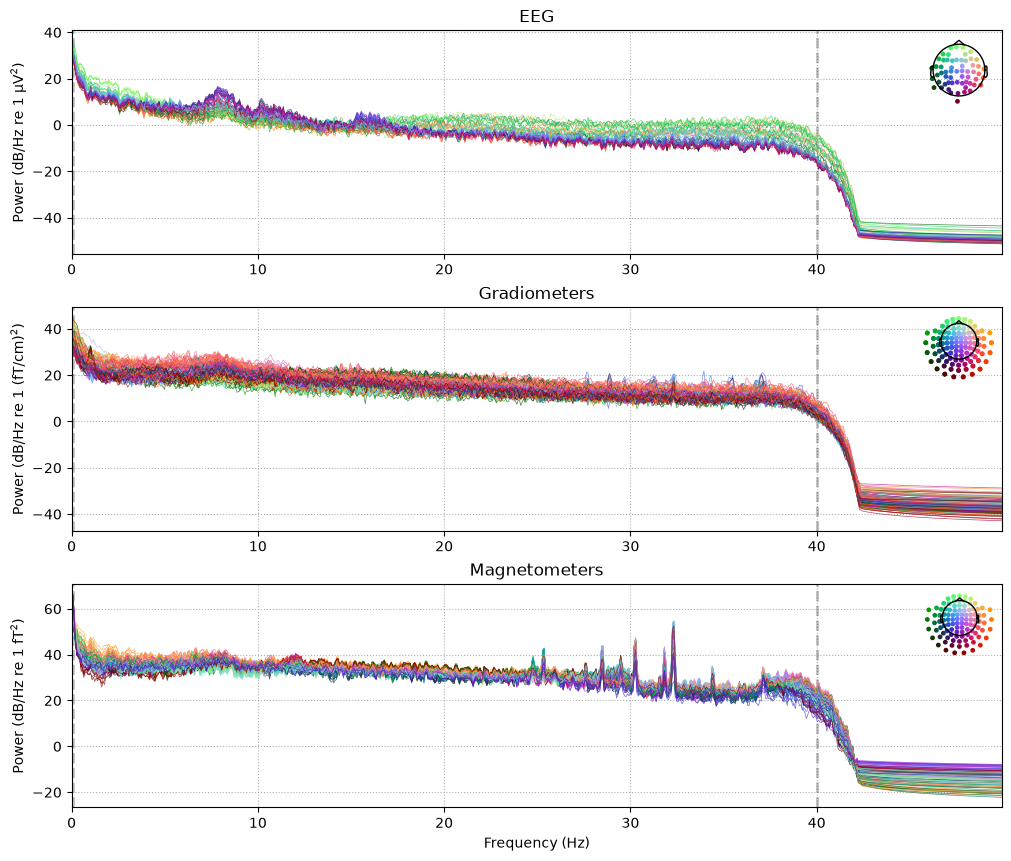

In [6]:
#Calculate and draw a frequency diagram (signal power spectrum)
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)

In [7]:
# Timeline graph of signals (similar to EEG monitors)
raw.plot(duration=5, n_channels=30)

<mne_qt_browser._pg_figure.MNEQtBrowser(0x233b4982ae0) at 0x00000233D099CA80>

# Extracting Events and Segmenting Data (`Events` & `Epochs` Object)

## Preprocessing

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 2.8s.
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


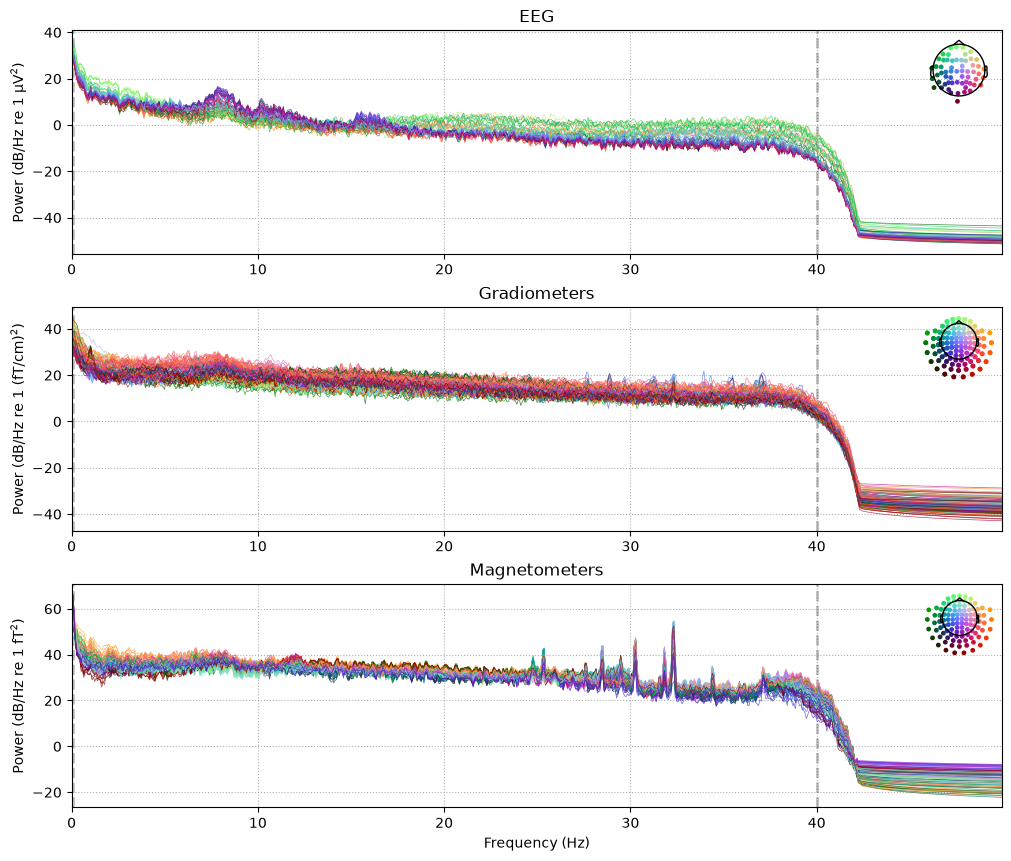

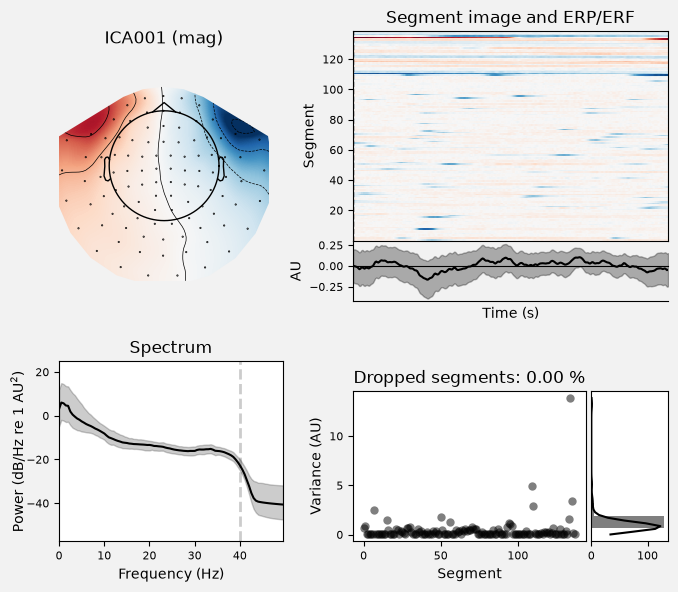

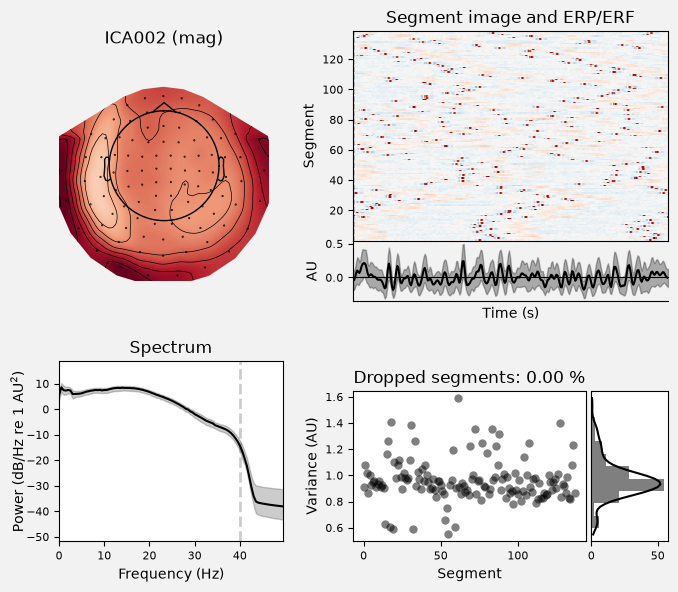

[<Figure size 700x600 with 6 Axes>, <Figure size 700x600 with 6 Axes>]

In [9]:
# Configuring and structuring the ICA model
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)

# Fitting or applying the model to raw data. 
# This command runs the heavy math calculations of the ICA algorithm on our raw signal to extract those 20 components.
ica.fit(raw)
# Specify noise components to remove
# Here, components 1 and 2 (which were likely blink noise or heartbeat noise) are placed on the exclude list to be removed from the brain signal in later stages.
ica.exclude = [1, 2]
# Plotting the characteristics and specifications of noise components
# This function plots statistical graphs and detailed characteristics of components 1 and 2 (such as the topographic map on the head, frequency spectrum, and time variations) so that the user can see with their own eyes why these two components are detected as noise.
ica.plot_properties(raw, picks=ica.exclude)

In [10]:
# Make a copy of the original data for later comparison
orig_raw = raw.copy()

# Completely load all data into RAM
raw.load_data()

# Apply ICA filter and completely remove noise components (which were identified in the previous step)
ica.apply(raw)

# Define the names of the desired frontal channels (mixture of MEG and EEG channels)
chs = [
    "MEG 0111", "MEG 0121", "MEG 0131", "MEG 0211", "MEG 0221", "MEG 0231",
    "MEG 0311", "MEG 0321", "MEG 0331", "MEG 1511", "MEG 1521", "MEG 1531",
    "EEG 001", "EEG 002", "EEG 003", "EEG 004", "EEG 005", "EEG 006", "EEG 007", "EEG 008"
]

# Find the index number (rank) of these channels in the main data array
chan_idxs = [raw.ch_names.index(ch) for ch in chs]

# Draw a time graph of the original signal and noise (for comparison)
orig_raw.plot(order=chan_idxs, start=12, duration=4)

# Plot the time graph of the cleaned signal after applying ICA
raw.plot(order=chan_idxs, start=12, duration=4)

Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 364 PCA components


<mne_qt_browser._pg_figure.MNEQtBrowser(0x2338954b000) at 0x000002338785FB80>

## Detecting experimental events

In [11]:
# Extract all events from STI channel 014
events = mne.find_events(raw, stim_channel="STI 014")
# mne.find_events: This function searches the entire signal and extracts the time and code wherever there is a pulse or voltage spike in the specified channel.
# stim_channel="STI 014": Tells the function exactly which stimulus channel to look at to find triggers.

# Display the first 5 extracted events
print(events[:5])
# This command prints the first 5 lines of the events array to the output.

Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[6994    0    2]
 [7086    0    3]
 [7192    0    1]
 [7304    0    4]
 [7413    0    2]]


What does the events array look like and what does it represent?
The output of this command is a matrix or multidimensional array (NumPy array) with each row representing an event and containing 3 columns:
* The first column (event time): The exact number of the sample of the signal in which the event occurred.
* The second column: Usually the previous voltage value of the channel (which is most often 0).
* The third column (event code or Event ID): An integer (such as 1, 2, 3, or 32) that indicates exactly what the event was. For example, in this dataset, code 1 means hearing sound in the left ear, code 2 means hearing sound in the right ear, and code 32 means pressing a button by the participant.

In [12]:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "smiley": 5,
    "buttonpress": 32,
}

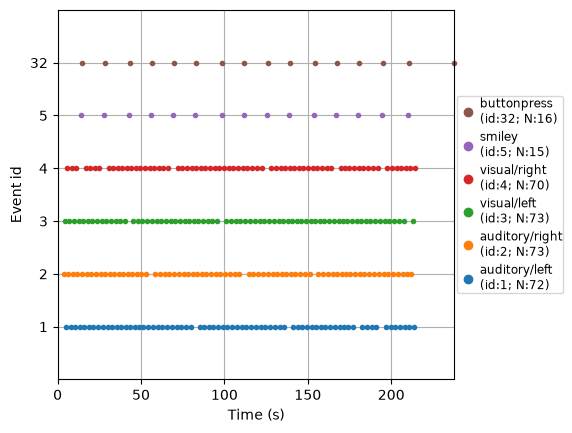

In [13]:
fig = mne.viz.plot_events(
    events,
    event_id=event_dict,
    sfreq=raw.info["sfreq"],
    first_samp=raw.first_samp,
)

In [14]:
# Define elimination criteria for different channels (eliminate severe noise spikes)
reject_criteria = dict(
    mag=4000e-15,   # MEG device magnetometer channels
    grad=4000e-13,  # MEG gradiometer channels
    eeg=150e-6,     # EEG channels (150 microvolts)
    eog=250e-6,     # EOG channels (250 microvolts)
)

In [15]:
# Create a fragmented Epochs object
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2,            # Start the epoch 200 milliseconds before the trigger
    tmax=0.5,             # End of epoch up to 500 milliseconds after trigger
    reject=reject_criteria, # Applying noise reduction criteria
    preload=True,         # Preload in RAM
)

Not setting metadata
319 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Using data from preloaded Raw for 319 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EEG : ['EEG 008']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
10 bad epochs dropped


In [16]:
# Identifying the conditions that are important to us
conds_we_care_about = ["auditory/left", "auditory/right", "visual/left", "visual/right"]

# Equalize the number of condition pieces (changes are applied directly to the variable itself)
epochs.equalize_event_counts(conds_we_care_about)

# Separating audio and visual parts using the slash (/) feature in the dictionary
aud_epochs = epochs["auditory"]
vis_epochs = epochs["visual"]

# Clear previously heavy variables to free up RAM space
del raw, epochs

Dropped 7 epochs: 121, 195, 258, 271, 273, 274, 275


Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
136 matching events found
No baseline correction applied
0 projection items activated


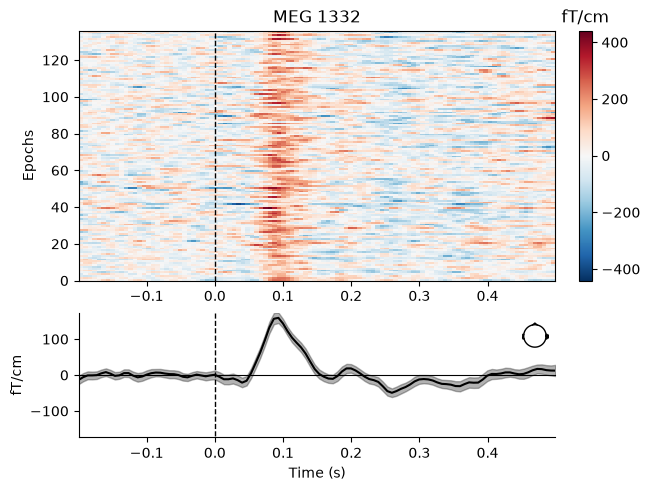

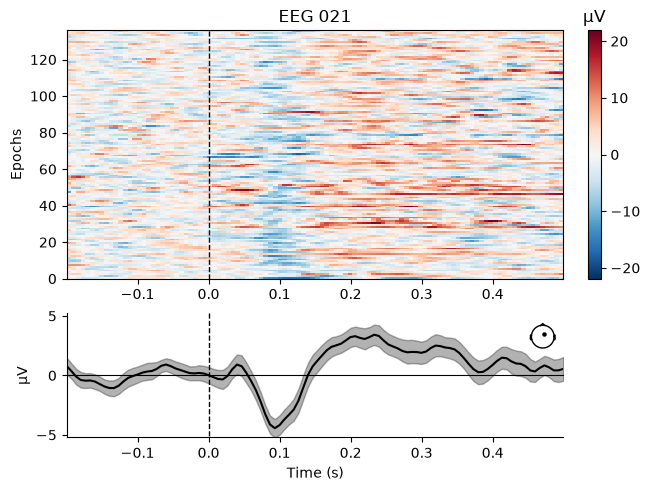

[<Figure size 640x480 with 4 Axes>, <Figure size 640x480 with 4 Axes>]

In [17]:
# Draw a visual graph for two specific channels (one MEG channel and one EEG channel)
aud_epochs.plot_image(picks=["MEG 1332", "EEG 021"])

In [18]:
# Define the desired frequency range for analysis
frequencies = np.arange(7, 30, 3)

This command creates an array of numbers that starts at 7 Hz and moves forward 3 steps, stopping before 30. This means that the frequencies we will be looking at will be: [7, 10, 13, 16, 19, 22, 25, 28] Hz. This range mostly includes `alpha` and `beta` brain waves.

In [19]:
# Calculating time-frequency transformation with the Morelet wavelet algorithm
power = aud_epochs.compute_tfr(
    "morlet", 
    n_cycles=2, 
    return_itc=False, 
    freqs=frequencies, 
    decim=3, 
    average=True
)

* `morlet:` Specifies that the Morlet wavelet formula should be used to extract frequencies (one of the most popular methods in brain signal processing).
* `n_cycles=2:` Sets the number of wavelet cycles to 2, which provides a balance between time accuracy and frequency accuracy.
* `return_itc=False:` Tells the system not to calculate the Inter-Trial Coherence index, and we only want the power and energy of the frequencies.
* `decim=3:` Scales the data to one-third the time dimension (downsampling) to reduce the amount of computation and speed up processing and plotting.
* `average=True:` Averages the output across all slices to give us an overall map of frequency power.

No baseline correction applied


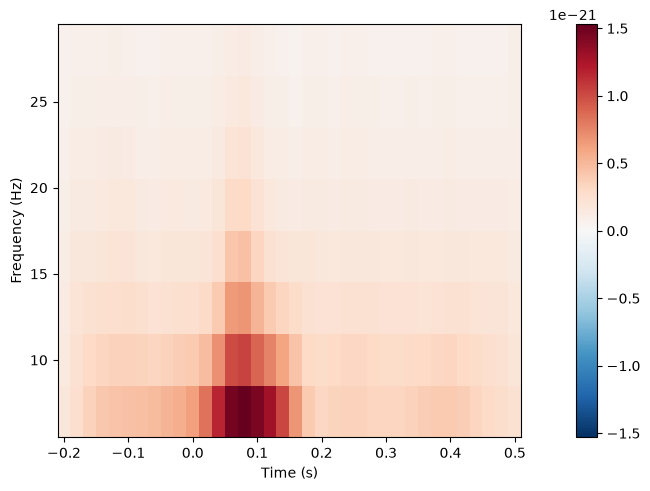

[<Figure size 640x480 with 2 Axes>]

In [20]:
# Draw a time-frequency diagram for a specific channel
power.plot(["MEG 1332"])

This method draws a two-dimensional color diagram (known as a Spectrogram or Contour Plot) for the `MEG 1332` magnetic channel. The horizontal axis of this diagram is `time`, the vertical axis is `frequency`, and the intensity of the colors indicates the amount of `energy or signal power` at that particular moment and frequency.

# Averaging and Extracting Event-Related Potentials (`Evoked` Object)

Multiple channel types selected, returning one figure per type.
combining channels using RMS (grad channels)
combining channels using RMS (grad channels)


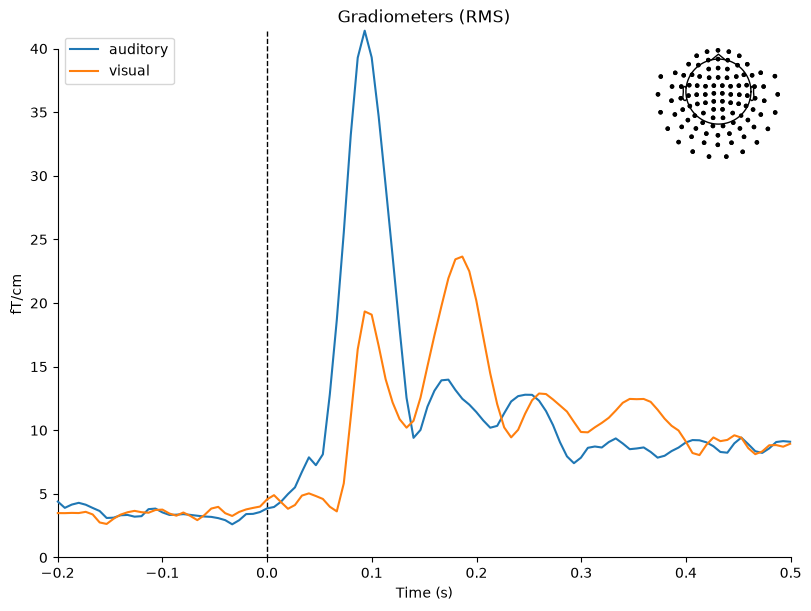

combining channels using RMS (mag channels)
combining channels using RMS (mag channels)


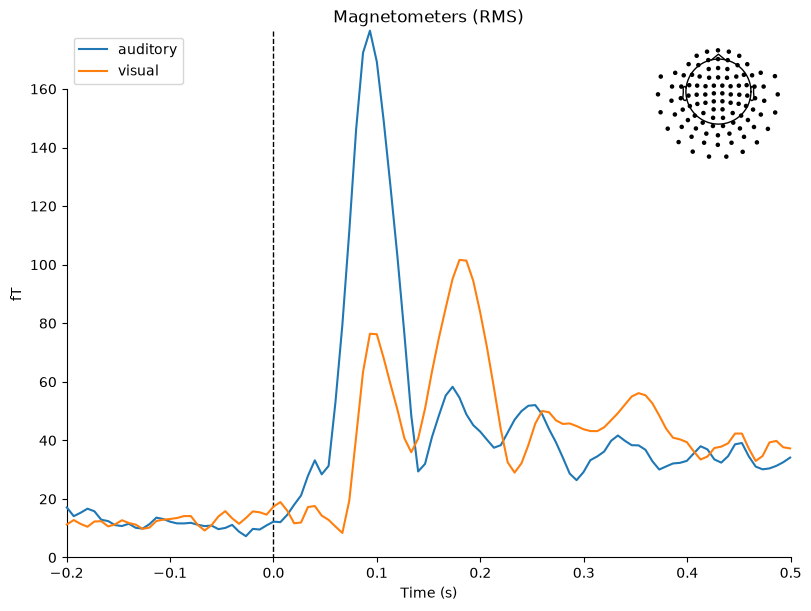

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


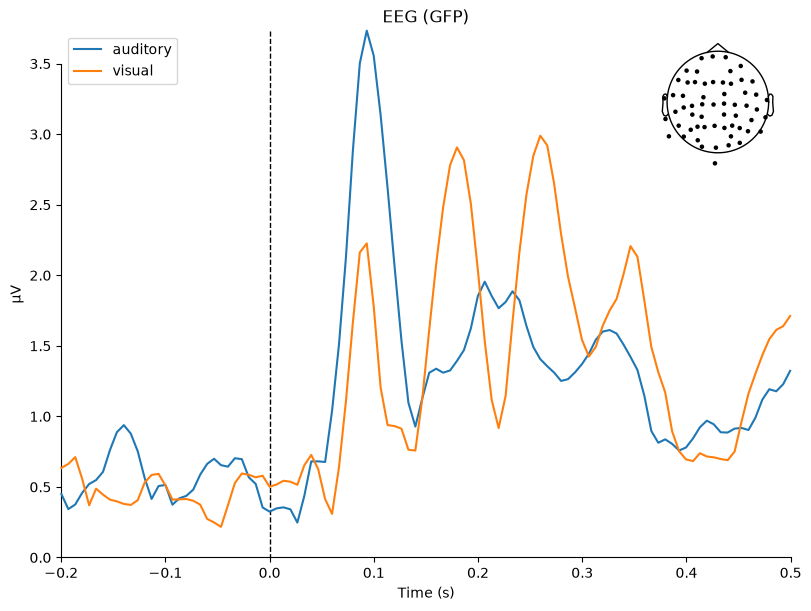

[<Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>,
 <Figure size 800x600 with 2 Axes>]

In [21]:
# Averaging of epochs to create Evoked objects (evoked response extraction)
aud_evoked = aud_epochs.average()
vis_evoked = vis_epochs.average()

# Draw a comparative diagram between auditory and visual response
mne.viz.plot_compare_evokeds(
    dict(auditory=aud_evoked, visual=vis_evoked),
    legend="upper left",        # Location of the chart guide at the top left
    show_sensors="upper right", # Display the position of the sensors in the top right
)

Projections have already been applied. Setting proj attribute to True.


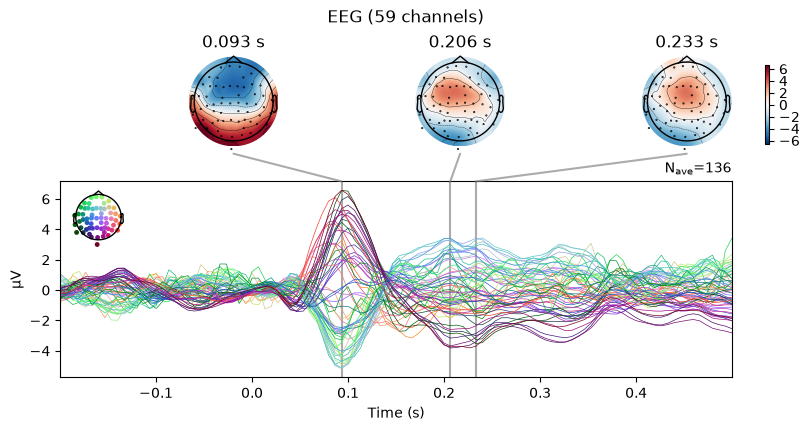

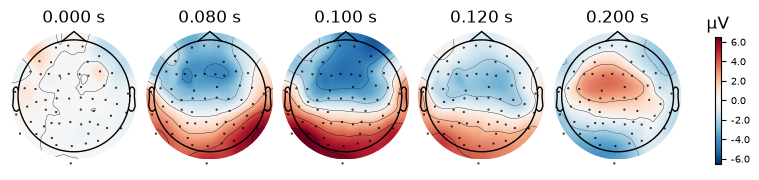

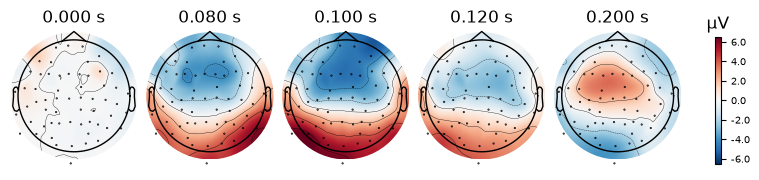

In [22]:
# Draw a combination chart (timeline chart of channels alongside topographic maps of signal peaks)
aud_evoked.plot_joint(picks="eeg")

# Draw colored topographic maps (Topomap) at specified times (in seconds)
aud_evoked.plot_topomap(times=[0.0, 0.08, 0.1, 0.12, 0.2], ch_type="eeg")

`times=[0.0, 0.08, ...]:` Specifies that the voltage distribution state on the scalp should be plotted as circular maps at exactly zero time (start of stimulus), 80 milliseconds, 100 milliseconds, 120 milliseconds, and 200 milliseconds after the stimulus.

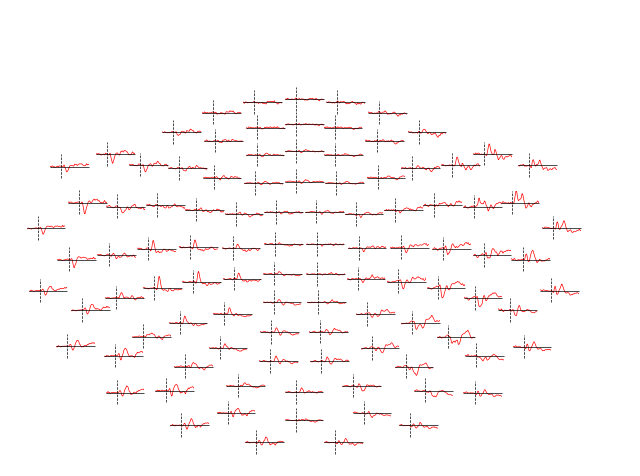

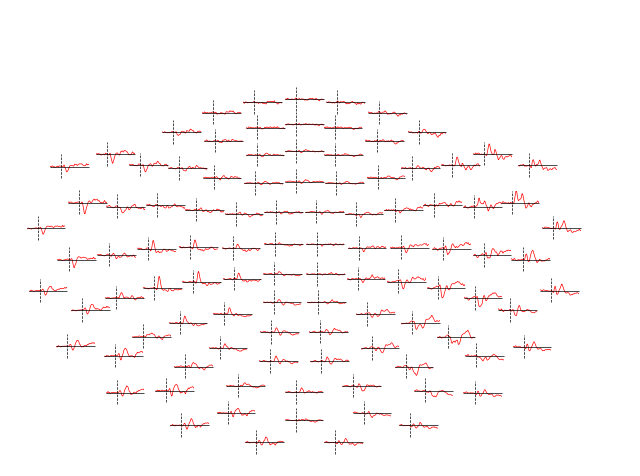

In [23]:
# Subtract the visual response from the auditory response to see their electrical differences
evoked_diff = mne.combine_evoked([aud_evoked, vis_evoked], weights=[1, -1])

# Selecting magnetometer channels (mag) and drawing a differential graph on the electrode topography map
evoked_diff.pick(picks="mag").plot_topo(color="r", legend=False)

# Source Localization & `SourceEstimate` (Inverse modeling)
At this stage, the data recorded from the scalp is sent into the brain (cortex) to find out exactly which brain area produced these signals.

In [24]:
# Load the precomputed inverse operator file
inverse_operator_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis-meg-oct-6-meg-inv.fif"
)
inv_operator = mne.minimum_norm.read_inverse_operator(inverse_operator_file)

# Set the signal-to-noise ratio (SNR) to calculate the regularization parameter (Landau to the power of 2)
snr = 3.0
lambda2 = 1.0 / snr**2

# Applying the inverse model and constructing the source time course (STC) variable for visual stimuli
stc = mne.minimum_norm.apply_inverse(
    vis_evoked, inv_operator, lambda2=lambda2, method="MNE"
)  # dSPM, sLORETA or eLORETA methods can also be selected

Reading inverse operator decomposition from C:\Users\Sara\mne_data\MNE-sample-data\MEG\sample\sample_audvis-meg-oct-6-meg-inv.fif...
    Reading inverse operator info...
    [done]
    Reading inverse operator decomposition...
    [done]
    305 x 305 full covariance (kind = 1) found.
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Noise covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 2) found.
    Source covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 6) found.
    Orientation priors read.
    22494 x 22494 diagonal covariance (kind = 5) found.
    Depth priors read.
    Did not find the desired covariance matrix (kind = 3)
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing p

`stc:` The output of this function is an object called SourceTimeCourse, or STC for short. This object actually contains information that shows how much electrical current each 3D part of the brain produced per millisecond.

In [25]:
# Specify the folder path of the participant's structural MRI files
subjects_dir = sample_data_folder / "subjects"

# Drawing and visualizing source activity on the 3D brain
stc.plot(
    initial_time=0.1, 
    hemi="split", 
    views=["lat", "med"], 
    subjects_dir=subjects_dir
)

Using pyvistaqt 3d backend.
Using control points [8.61922423e-11 1.06837855e-10 4.49139511e-10]


* `initial_time=0.1:` Opens the 3D diagram of the brain at exactly 100 milliseconds (0.1 seconds) after the stimulus is presented to watch the brain's activity at that moment.
* `hemi="split":` Shows the image of the two hemispheres of the brain (right and left) separately and separated side by side.
* `views=["lat", "med"]:` Shows the brain from two viewing angles, lateral or outer and medial or inner, so that both the activities of the outer cortex and the inner parts of the brain are fully visible.